# Лабораторная работа № 1. Определение типа процесса временного ряда

# 1 Цель работы
Определить, к какому типу процесса относится временной ряд для возможности построения в дальнейшем качественного прогноза.

## 1.1 Задачи
1. На основе анализа графика исходного ряда сделать предположение о типе процесса.
2. На основе анализа коррелограмм автокорреляционной функции (ACF/АКФ) и частной автокорреляционной функции (PACF/ЧАКФ) для исходного ряда, его первых и вторых разностей сделать предварительный вывод о типе процесса.
3. На основе процедуры Доладо, Дженкинса и Сосвилло-Ривера с применением расширенного теста Дики-Фуллера определить тип процесса временного ряда.
4. Сделать итоговое заключение.


# 2 Теоретическая справка
# 2.1 Типы процессов временного ряда
Временной ряд (time-series) – ряд последовательных значений, характеризующих изменение показателя во времени.
Временные ряды могут быть стационарными и нестационарными Временной ряд называется стационарным, если его вероятностные характеристики (математическое ожидание, дисперсия) постоянны. Временной ряд называется нестационарным, если хотя бы одна из вероятностных характеристик непостоянна. На практике часто встречаются нестационарные временные ряды.

Два разных типа нестационарных по отношению к среднему временных рядов могут быть приведены к стационарному виду с помощью взятия последовательных разностей. Это ряды с детерминированным трендом (TS – Trend Stationary) и ряды, имеющие стохастический процесс (DS – Difference Stationary).

Принципиальное различие между этими двумя типами рядов выражается в том, что TS ряд можно привести к стационарному виду с помощью выделения линейного тренда, тогда как вычитание детерминированной составляющей из DS ряда оставляет его нестационарным.

Выделим типы процессов, к которым временные ряды часто относятся на практике:
1.	TS (Trend Stationary) – детерминированный тренд.
2.	DS (Difference Stationary) – стахостический процесс. Выделяют несколько видов DS-процесса, а именно:
    2.1. DS I(0) – ряд сразу является стационарным,
    2.2. DS I(1) – ряд становится стационарным на 1-ых разностях,
    2.3. DS I(2) – ряд становится стационарным на 2-ых разностях,
    2.4. TS+DS – стохастический тренд.

Вид уравнения в зависимости от типа процесса:
- TS+DS: $\Delta^2 y_t=\alpha_0 + \alpha_1 \Delta y_{t-1} + bt + \sum_{i=1}^{n} \beta_i \Delta^2 y_{t-i}$
- TS: $\Delta y_t=\alpha_0 + bt + \sum_{i=1}^{n} \beta_i \Delta^2 y_{t-i}$
- DS I(1): $\Delta^2 y_t=\alpha_1 \Delta y_{t-1} + \sum_{i=1}^{n} \beta_i \Delta^2 y_{t-i}$
- DS I(2): $\Delta^3 y_t= \alpha_1 \Delta^2 y_{t-1} + \sum_{i=1}^{n} \beta_i \Delta^3 y_{t-i}$
- DS I(0): $\Delta y_t=\alpha_1 y_{t-1} + bt + \sum_{i=1}^{n} \beta_i \Delta y_{t-i}$

## 2.2 Определение типа процесса
Типы процессов определяются на основе результатов тестов Дикки-Фуллера (ADF) с различными параметрами. Определим следующие тесты:
- Тест 1: 1st difference, trend and intercept
- Тест 2: level, Trend and intercept
- Тест 3: 2nd difference, none
- Тест 3 (расш.): 2nd difference, intercept
- Тест 4: 1st difference, none
- Тест 4 (расш.): 1st difference, intercept
- Тест 5: level, none
- Тест 5: level, intercept

Тест считается выполненным, если:
1. Выполняется проверка на единичный корен: если t-статистика лежит левее критического значения MacKinnon (p-value), то есть $t_{расч} \leq t_{табл}$, то нулевая гипотеза отвергается. Отвержение нулевой гипотезы говорит об отсутствии необходимости брать разности для приведения ряда к стационарному виду.
2. Проверка на статистическую значиомсть F-статистики: если $Prob(F_{стат}) < 0.05$, то F-стат является значимой.
3. Все остальные коэффициенты статистически значимы, то есть соотносящиеся им уровни доверительной вероятности $p-value < 0.05$. Если не все лаговые переменные статистически значимы, то следует изменить длину максимального лага запаздывания в специальном тесте на единичный корень на меньшую длину.
4. Статистика Durbin-Watson Stat. должна лежать в границах 1.6 и 2.4
5. Коэффициент детерминации $R^2$ должен стремиться к 1.

Тип процесса определяется по результатам проделанных тестов:

| Процесс    | Результаты теста                                                                                   |
| ---------- | -------------------------------------------------------------------------------------------------- |
| TS+DS      | Выполняется 1, 4, 2 (статистически значимый тренд) тест.<br>3, 5 тест не выполняются.              |
| TS         | 1 тест (trend значим).<br>2 тест выполняется.<br>3, 4, 5 не выполняются.                           |
| DS ($I_2$) | 3 тест выполняется или его модификация.<br>Возможно выполняется 1 тест.<br>2, 4, 5 не выполняются. |
| DS ($I_1$) | 3 тест выполняется.<br>4 тест выполняется или его модификация.<br>1, 2, 5 тесты не выполняются.    |
| DS ($I_0$) | 3, 4 тесты выполняются.<br>5 тест выполняется или его модификация.<br>1, 2 тесты не выполняются.   |

Тест Дикки-Фуллера может дать ошибку, если есть структурные скачки.


# 3 Практическая часть
Исследуется временной ряд среднесуточной температуры воздуха в Уфе за период с 1 января 2019 года по 22 марта 2026 года.


## 3.1 Чтение временного ряда
Для считывания временного ряда из исходного датасета реализована функция `read_ts`, принимающая на вход путь к csv-файлу с данными датасета, название колонки, в которой указана дата, и название колонки, содержащей значения временного ряда. Функция `read_ts` возвращает объект типа `pandas.Series` для корректной работы с временным рядом.

In [23]:
import warnings

import numpy as np
import pandas as pd
import statsmodels.api as sm
from IPython.display import display
from matplotlib import pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

warnings.filterwarnings("ignore", category=UserWarning)


def read_ts(filepath: str, datetime_col: str, data_col: str,
            skiprows: int = 0, dayfirst: bool = False) -> pd.Series:
    df = pd.read_csv(filepath, skiprows=skiprows)
    df[datetime_col] = pd.to_datetime(df[datetime_col], dayfirst=dayfirst)
    df = df.set_index(datetime_col).sort_index()
    return df[data_col].copy()

ts = read_ts("data/timeseries.csv", "time", "shortwave_radiation_sum (MJ/m²)", skiprows=3).asfreq("D")
summary_raw = (
    ("Количество наблюдений",      len(ts)),
    ("Начальная дата",             ts.index.min().strftime("%d.%m.%Y")),
    ("Конечная дата",              ts.index.max().strftime("%d.%m.%Y")),
    ("Среднее, МДж/м²",           round(ts.mean(), 3)),
    ("Ст. отклонение, МДж/м²",    round(ts.std(), 3)),
    ("Минимум, МДж/м²",           round(ts.min(), 3)),
    ("Максимум, МДж/м²",          round(ts.max(), 3)),
)
summary_df = pd.DataFrame({
    "Показатель": [metric for metric, value in summary_raw],
    "Значение": [value for metric, value in summary_raw],
})
display(summary_df)

,Показатель,Значение
0,Количество наблюдений,2652
1,Начальная дата,01.01.2019
2,Конечная дата,05.04.2026
3,"Среднее, МДж/м²",11.218
4,"Ст. отклонение, МДж/м²",8.415
5,"Минимум, МДж/м²",0.38
6,"Максимум, МДж/м²",30.25


## 3.2 Анализ графика исходного ряда


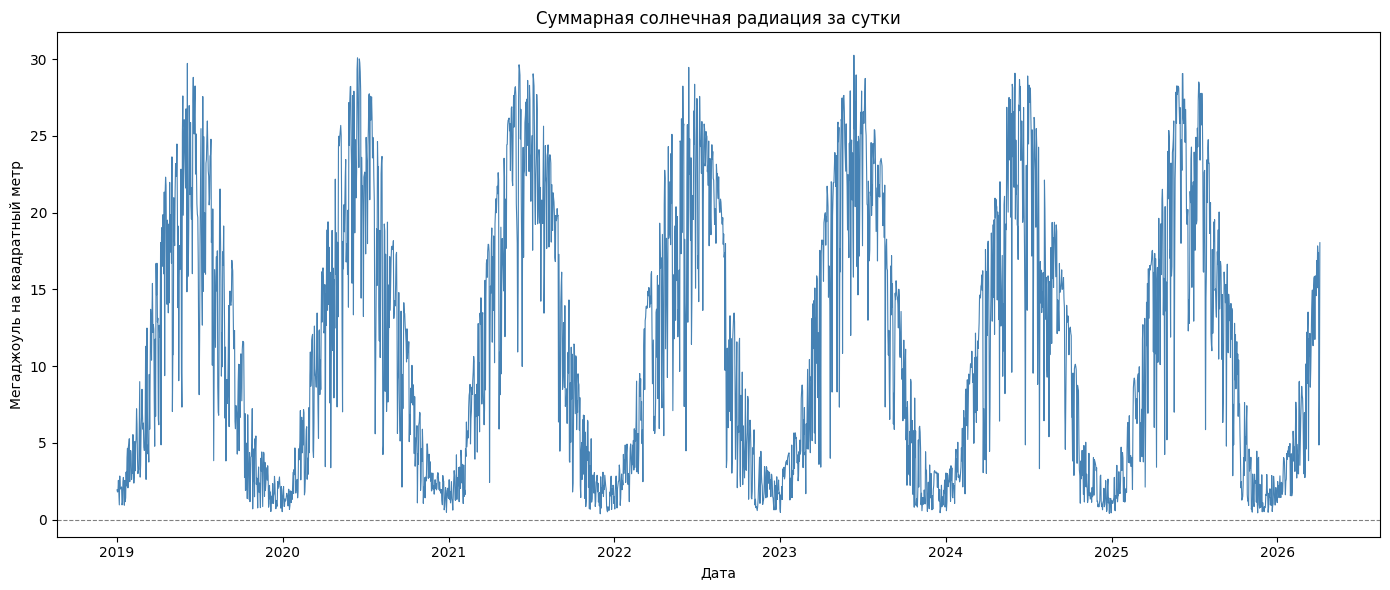

In [40]:
plt.figure(figsize=(14, 6))
plt.plot(ts.index, ts.values, color="steelblue", linewidth=0.8)
plt.axhline(0, color="gray", linestyle="--", linewidth=0.8)
plt.title("Суммарная солнечная радиация за сутки")
plt.xlabel("Дата")
plt.ylabel("Мегаджоуль на квадратный метр")
plt.tight_layout()
plt.show()


По графику видно, что ряд имеет выраженную годовую сезонность: чередование холодных и теплых периодов повторяется из года в год. При этом устойчивого линейного детерминированного тренда не наблюдается, а амплитуда колебаний остается примерно одного порядка.

Следовательно, исходный ряд нельзя считать стационарным по среднему в обычном смысле из-за сезонных сдвигов. Однако по характеру колебаний он больше похож на ряд с выраженной детерминированной сезонной компонентой, чем на процесс с накапливающимся стохастическим трендом. Предварительная рабочая гипотеза: DS(I0).


## 3.3 Анализ коррелограмм АКФ и ЧАКФ
Для выявления структуры зависимости строятся коррелограммы исходного ряда, а также его первых и вторых разностей.


In [25]:
def plot_correlograms(series: pd.Series, lags: int, title: str):
    """
    По заданному ряда строит коррелограммы АКФ и ЧАКФ
    :param series: ряд
    :param lags: количество лагов
    :param title: заголовок для графика
    """
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    plot_acf(series, ax=axes[0], lags=lags, auto_ylims=True)
    axes[0].set_title("АКФ")
    plot_pacf(series, ax=axes[1], lags=lags, auto_ylims=True, method="ywm")
    axes[1].set_title("ЧАКФ")
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()


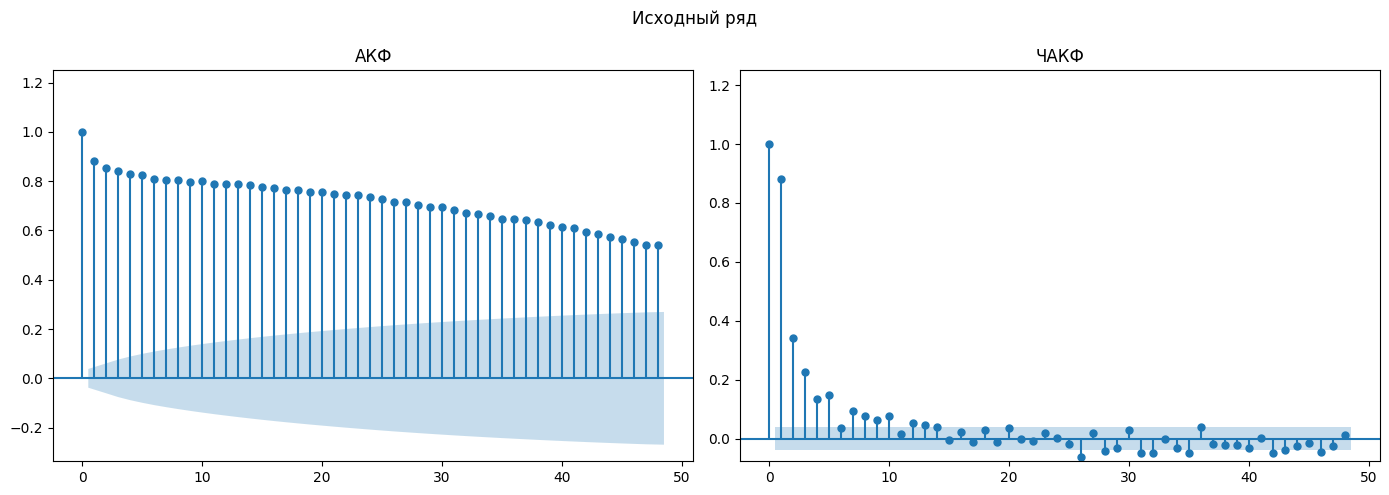

In [26]:
plot_correlograms(ts, lags=48, title="Исходный ряд")


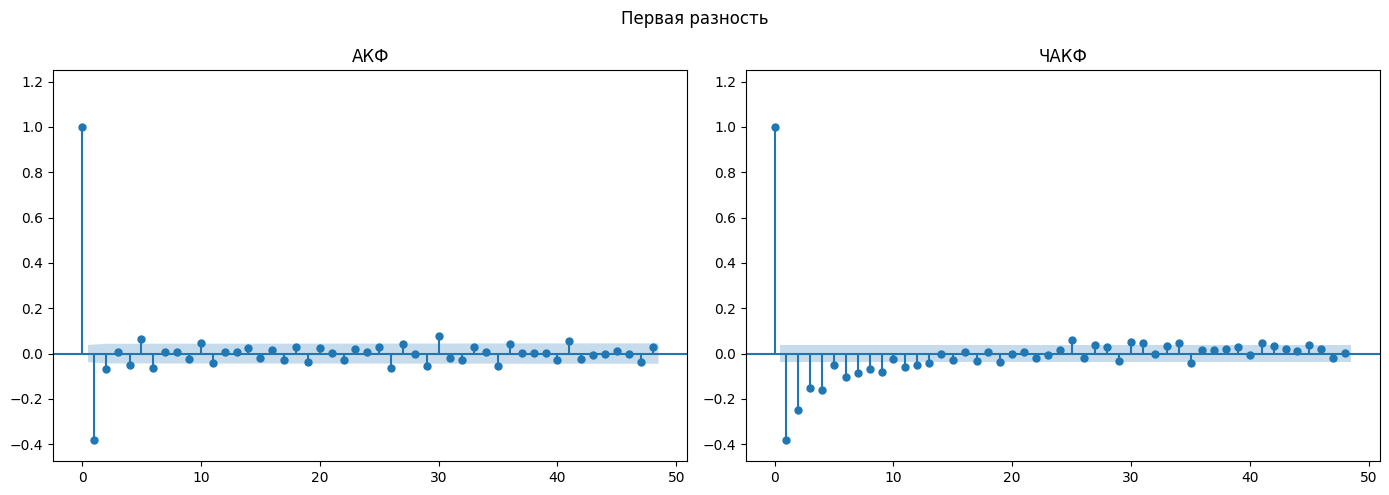

In [27]:
ts_diff1 = ts.diff().dropna()
plot_correlograms(ts_diff1, lags=48, title="Первая разность")


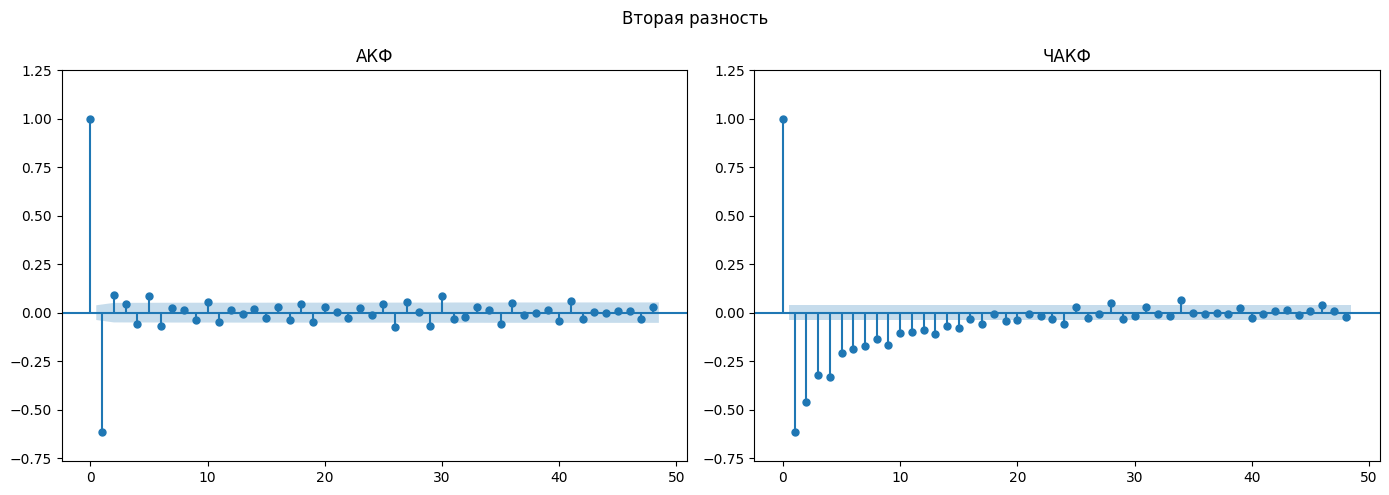

In [28]:
ts_diff2 = ts_diff1.diff().dropna()
plot_correlograms(ts_diff2, lags=48, title="Вторая разность")


Коррелограммы подтверждают визуальные наблюдения:
- для исходного ряда АКФ затухает медленно и имеет выраженную волнообразную форму;
- после первой разности зависимость заметно ослабевает;
- вторая разность делает ряд еще более «шумовым», что похоже на избыточное дифференцирование.

По совокупности графика и коррелограмм наиболее правдоподобной остается гипотеза DS(I0) с сильной детерминированной сезонной компонентой.


## 3.4 Выполнение тестов Дики-Фуллера
Ниже для каждого теста:
1. Выбирается стартовый лаг по AIC;
2. При необходимости лаг уменьшается до спецификации со значимыми вспомогательными коэффициентами;
3. Проверяется выполнение теста по ADF-статистике, общей значимости, значимости вспомогательных коэффициентов и статистике Дарбина-Уотсона.


In [29]:
from dataclasses import dataclass
from typing import Literal

from statsmodels.stats.stattools import durbin_watson
from statsmodels.tsa.stattools import adfuller


@dataclass
class AdfResult:
    test_name: str
    series_name: str
    regression: str
    initial_lag: int
    final_lag: int
    adf_stat: float
    p_value: float
    critical_values: dict
    f_stat: float
    f_pvalue: float
    rsquared: float
    dw: float
    coef_pvalues: dict[str, float]
    aux_pvalues: dict[str, float]
    all_aux_significant: bool


def optimize_adf_test(series: pd.Series, regression: Literal["n", "c", "ct"], test_name: str,
                      series_name: str) -> AdfResult:
    series = pd.Series(series).dropna().astype(float)
    _, _, initial_lag, *_ = adfuller(series, regression=regression, autolag="AIC")

    chosen = None
    for lag in range(initial_lag, -1, -1):
        adf_stat, p_value, crit_vals, store = adfuller(
            series,
            regression=regression,
            maxlag=lag,
            autolag=None,
            regresults=True,
        )
        res = store.resols
        coef_names = list(res.model.exog_names)
        coef_pvalues = pd.Series([float(v) for v in res.pvalues], index=coef_names)
        aux_pvalues = coef_pvalues.iloc[1:]
        all_aux_significant = bool((aux_pvalues < 0.05).all()) if len(aux_pvalues) else True

        chosen = AdfResult(
            test_name=test_name,
            series_name=series_name,
            regression=regression,
            initial_lag=int(initial_lag),
            final_lag=int(lag),
            adf_stat=float(adf_stat),
            p_value=float(p_value),
            critical_values={k: float(v) for k, v in crit_vals.items()},
            f_stat=float(res.fvalue),
            f_pvalue=float(res.f_pvalue),
            rsquared=float(res.rsquared),
            dw=float(durbin_watson(res.resid)),
            coef_pvalues={k: float(v) for k, v in coef_pvalues.items()},
            aux_pvalues={k: float(v) for k, v in aux_pvalues.items()},
            all_aux_significant=all_aux_significant,
        )

        if all_aux_significant:
            break

    return chosen


def display_test_details(result):
    print(f"=== Тест {result.test_name}: {result.series_name}, regression='{result.regression}' ===")
    details_raw = (
        ("Стартовый лаг",   result.initial_lag),
        ("Итоговый лаг",    result.final_lag),
        ("ADF",             round(result.adf_stat, 4)),
        ("p-value",         round(result.p_value, 6)),
        ("Крит. 5%",        round(result.critical_values["5%"], 4)),
        ("F-стат",          round(result.f_stat, 4)),
        ("Prob(F-стат)",    round(result.f_pvalue, 6)),
        ("R^2",             round(result.rsquared, 4)),
        ("DW",              round(result.dw, 4)),
    )
    details_df = pd.DataFrame({
        "Показатель": [metric for metric, value in details_raw],
        "Значение": [value for metric, value in details_raw],
    })
    display(details_df)

    coef_df = pd.DataFrame({
        "Коэффициент": list(result.coef_pvalues.keys()),
        "p-value": list(result.coef_pvalues.values()),
        "Вспомогательный": ["нет"] + ["да"] * (len(result.coef_pvalues) - 1),
    })
    coef_df["Значим при 5%"] = coef_df["p-value"].apply(lambda p: "да" if p < 0.05 else "нет")
    display(coef_df)

In [30]:
tests = [
    ("1", "Первая разность", ts_diff1, "ct"),
    ("2", "Исходный ряд", ts, "ct"),
    ("3", "Вторая разность", ts_diff2, "n"),
    ("3 (расш.)", "Вторая разность", ts_diff2, "c"),
    ("4", "Первая разность", ts_diff1, "n"),
    ("4 (расш.)", "Первая разность", ts_diff1, "c"),
    ("5", "Исходный ряд", ts, "n"),
    ("5 (расш.)", "Исходный ряд", ts, "c"),
]

adf_results = [optimize_adf_test(series, regression, test_name, series_name) for
               test_name, series_name, series, regression in tests]


### 3.4.1 Тест 1: первая разность, константа + тренд

In [31]:
display_test_details(adf_results[0])

=== Тест 1: Первая разность, regression='ct' ===


,Показатель,Значение
0,Стартовый лаг,12.0000
1,Итоговый лаг,0.0000
2,ADF,-76.7496
3,p-value,0.0000
4,Крит. 5%,-3.4121
5,F-стат,2945.2542
6,Prob(F-стат),0.0000
7,R^2,0.6900
8,DW,2.1857


,Коэффициент,p-value,Вспомогательный,Значим при 5%
0,x1,0.000000,нет,да
1,const,0.916577,да,нет
2,x2,0.947330,да,нет


### 3.4.2 Тест 2: исходный ряд, константа + тренд

In [32]:
display_test_details(adf_results[1])

=== Тест 2: Исходный ряд, regression='ct' ===


,Показатель,Значение
0,Стартовый лаг,13.0000
1,Итоговый лаг,0.0000
2,ADF,-12.8879
3,p-value,0.0000
4,Крит. 5%,-3.4121
5,F-стат,83.0496
6,Prob(F-стат),0.0000
7,R^2,0.0590
8,DW,2.6004


,Коэффициент,p-value,Вспомогательный,Значим при 5%
0,x1,6.613937e-37,нет,да
1,const,1.990092e-13,да,да
2,x2,6.794847e-01,да,нет


### 3.4.3 Тест 3: вторая разность, ничего

In [33]:
display_test_details(adf_results[2])

=== Тест 3: Вторая разность, regression='n' ===


,Показатель,Значение
0,Стартовый лаг,28.0000
1,Итоговый лаг,28.0000
2,ADF,-20.3314
3,p-value,0.0000
4,Крит. 5%,-1.9411
5,F-стат,969.5109
6,Prob(F-стат),0.0000
7,R^2,0.9156
8,DW,2.0131


,Коэффициент,p-value,Вспомогательный,Значим при 5%
0,x1,2.190908e-85,нет,да
1,x2,2.097788e-78,да,да
2,x3,6.773696e-74,да,да
3,x4,2.560901e-69,да,да
4,x5,8.807368e-65,да,да
5,x6,1.581372e-60,да,да
6,x7,2.091132e-56,да,да
7,x8,1.865451e-52,да,да
8,x9,1.047903e-48,да,да
9,x10,3.956594e-45,да,да


### 3.4.4 Тест 3 (расш.): вторая разность, константа

In [34]:
display_test_details(adf_results[3])

=== Тест 3 (расш.): Вторая разность, regression='c' ===


,Показатель,Значение
0,Стартовый лаг,28.0000
1,Итоговый лаг,0.0000
2,ADF,-105.1115
3,p-value,0.0000
4,Крит. 5%,-2.8626
5,F-стат,11048.4251
6,Prob(F-стат),0.0000
7,R^2,0.8067
8,DW,2.5634


,Коэффициент,p-value,Вспомогательный,Значим при 5%
0,x1,0.000000,нет,да
1,const,0.965102,да,нет


### 3.4.5 Тест 4: первая разность, ничего

In [35]:
display_test_details(adf_results[4])

=== Тест 4: Первая разность, regression='n' ===


,Показатель,Значение
0,Стартовый лаг,12.0000
1,Итоговый лаг,12.0000
2,ADF,-20.9988
3,p-value,0.0000
4,Крит. 5%,-1.9411
5,F-стат,557.0551
6,Prob(F-стат),0.0000
7,R^2,0.7340
8,DW,1.9987


,Коэффициент,p-value,Вспомогательный,Значим при 5%
0,x1,1.266838e-90,нет,да
1,x2,3.251483e-38,да,да
2,x3,6.334353e-29,да,да
3,x4,3.983525e-23,да,да
4,x5,2.147793e-18,да,да
5,x6,5.452669e-16,да,да
6,x7,1.084192e-12,да,да
7,x8,4.200366e-10,да,да
8,x9,5.010230e-08,да,да
9,x10,4.341280e-06,да,да


### 3.4.6 Тест 4 (расш.): первая разность, константа

In [36]:
display_test_details(adf_results[5])

=== Тест 4 (расш.): Первая разность, regression='c' ===


,Показатель,Значение
0,Стартовый лаг,12.0000
1,Итоговый лаг,0.0000
2,ADF,-76.7641
3,p-value,0.0000
4,Крит. 5%,-2.8626
5,F-стат,5892.7196
6,Prob(F-стат),0.0000
7,R^2,0.6900
8,DW,2.1857


,Коэффициент,p-value,Вспомогательный,Значим при 5%
0,x1,0.00000,нет,да
1,const,0.92423,да,нет


### 3.4.7 Тест 5: исходный ряд, ничего

In [37]:
display_test_details(adf_results[6])

=== Тест 5: Исходный ряд, regression='n' ===


,Показатель,Значение
0,Стартовый лаг,13.000000
1,Итоговый лаг,13.000000
2,ADF,-1.496900
3,p-value,0.125967
4,Крит. 5%,-1.941100
5,F-стат,68.218600
6,Prob(F-стат),0.000000
7,R^2,0.266800
8,DW,1.998600


,Коэффициент,p-value,Вспомогательный,Значим при 5%
0,x1,1.345362e-01,нет,нет
1,x2,6.655405e-157,да,да
2,x3,1.720435e-77,да,да
3,x4,8.552102e-42,да,да
4,x5,1.567417e-32,да,да
5,x6,4.543218e-16,да,да
6,x7,8.786986e-20,да,да
7,x8,2.010526e-14,да,да
8,x9,1.184545e-10,да,да
9,x10,5.761681e-09,да,да


### 3.4.8 Тест 5 (расш.): исходный ряд, константа

In [38]:
display_test_details(adf_results[7])

=== Тест 5 (расш.): Исходный ряд, regression='c' ===


,Показатель,Значение
0,Стартовый лаг,13.000000
1,Итоговый лаг,13.000000
2,ADF,-3.040500
3,p-value,0.031284
4,Крит. 5%,-2.862600
5,F-стат,68.881100
6,Prob(F-стат),0.000000
7,R^2,0.268800
8,DW,1.998400


,Коэффициент,p-value,Вспомогательный,Значим при 5%
0,x1,2.385452e-03,нет,да
1,x2,1.085814e-137,да,да
2,x3,4.155893e-69,да,да
3,x4,2.455744e-37,да,да
4,x5,2.821628e-29,да,да
5,x6,2.871960e-14,да,да
6,x7,6.117246e-18,да,да
7,x8,4.253526e-13,да,да
8,x9,1.085613e-09,да,да
9,x10,3.334995e-08,да,да


### 3.5 Итоговый вывод

In [39]:
def evaluate_test(result: AdfResult) -> dict:
    unit_root_rejected = result.adf_stat <= result.critical_values["5%"] and result.p_value < 0.05
    f_ok = result.f_pvalue < 0.05
    dw_ok = 1.6 <= result.dw <= 2.4
    verdict = unit_root_rejected and f_ok and result.all_aux_significant and dw_ok

    return {
        "Тест": result.test_name,
        "Кол-во лагов": result.initial_lag,
        "ADF": round(result.adf_stat, 4),
        "p-value": round(result.p_value, 6),
        "Prob(F-стат)": round(result.f_pvalue, 6),
        "R²": round(result.rsquared, 4),
        "DW": round(result.dw, 4),
        "Все коэф. значимы?": "Да" if result.all_aux_significant else "Нет",
        "Тест выполняется?": "Да" if verdict else "Нет",
    }

adf_summary_df = pd.DataFrame([evaluate_test(result) for result in adf_results])
display(adf_summary_df)


,Тест,Кол-во лагов,ADF,p-value,Prob(F-стат),R²,DW,Все коэф. значимы?,Тест выполняется?
0,1,12,-76.7496,0.000000,0.0,0.6900,2.1857,Нет,Нет
1,2,13,-12.8879,0.000000,0.0,0.0590,2.6004,Нет,Нет
2,3,28,-20.3314,0.000000,0.0,0.9156,2.0131,Да,Да
3,3 (расш.),28,-105.1115,0.000000,0.0,0.8067,2.5634,Нет,Нет
4,4,12,-20.9988,0.000000,0.0,0.7340,1.9987,Да,Да
5,4 (расш.),12,-76.7641,0.000000,0.0,0.6900,2.1857,Нет,Нет
6,5,13,-1.4969,0.125967,0.0,0.2668,1.9986,Да,Нет
7,5 (расш.),13,-3.0405,0.031284,0.0,0.2688,1.9984,Да,Да


- тест 0 не выполняется (не все коэффициенты значимы);
- тесты 1 не выполняется (не все коэффициенты значимы);
- тест 2 выполняется;
- тест 3 (расширенный) не выполняется (не все коэффициенты значимы);
- тест 4 выполняется;
- тест 5 не выполняется (p-value = 0.126 > 0.05, единичный корень не отвергается);
- тест 5 (расширенный) выполняется.

Тесты 3 и 4 выполняются, тест 5 не выполняется, а его модификация (расширенный тест 5) — выполняется.
Тесты 1 и 2 (на уровне и первой разности с трендом) не выполняются.

Такое сочетание в точности соответствует DS(I1): ряд становится стационарным на первых разностях, а константа в модели статистически значима.
Следовательно, временной ряд солнечной радиации в Уфе по результатам лабораторной работы следует классифицировать как процесс типа DS(I1).

При этом ряд содержит выраженную детерминированную сезонную компоненту,
которая не отменяет вывод о порядке интегрированности, но должна быть
отдельно выделена на следующих этапах анализа.
